In [1]:
# 08 - Random Forest Classifier on Breast Cancer Dataset

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn import metrics
from sklearn.tree import plot_tree
from sklearn.metrics import (confusion_matrix, accuracy_score,
    classification_report)

In [3]:
data = pd.read_csv('datasets/Breast_Cancer_Detection_Classification_Master.csv')
print("Shape:", data.shape)
print(data.head())
print()
print("Class distribution (B=benign, M=malignant):")
print(data['diagnosis'].value_counts())

Shape: (569, 32)
         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave_points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  radius_worst  texture_worst  perimete

In [4]:
print("Null values (first 5):", data.isnull().sum().head().tolist())

Null values (first 5): [0, 0, 0, 0, 0]


In [5]:
X = data.drop(columns=['id', 'diagnosis']).values
y = data['diagnosis'].map({'B': 0, 'M': 1}).values

print("X shape:", X.shape, "y shape:", y.shape)

X shape: (569, 30) y shape: (569,)


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=41
)
print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (398, 30) Test: (171, 30)


In [7]:
sc = StandardScaler()
X_train_scaled = sc.fit_transform(X_train)
X_test_scaled  = sc.transform(X_test)
print("Standardised.")

Standardised.


In [8]:
# Train Random Forest (n_estimators=10, entropy)

In [9]:
model = RandomForestClassifier(n_estimators=10, criterion='entropy',
                                random_state=0)
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

print("First 20 predictions:", y_pred[:20])
print("First 20 actual     :", y_test[:20])

First 20 predictions: [0 0 0 0 0 0 1 1 1 0 1 1 1 0 0 0 0 0 0 0]
First 20 actual     : [0 0 0 0 0 0 1 1 1 0 1 1 1 0 0 0 0 0 0 0]


In [10]:
cm = confusion_matrix(y_test, y_pred)
print("Random Forest Classifier")
print("Confusion Matrix:")
print(cm)
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)
print()
print(classification_report(y_pred, y_test,
      target_names=['Benign', 'Malignant']))

Random Forest Classifier
Confusion Matrix:
[[108   2]
 [  0  61]]
Accuracy: 0.9883040935672515

              precision    recall  f1-score   support

      Benign       0.98      1.00      0.99       108
   Malignant       1.00      0.97      0.98        63

    accuracy                           0.99       171
   macro avg       0.99      0.98      0.99       171
weighted avg       0.99      0.99      0.99       171



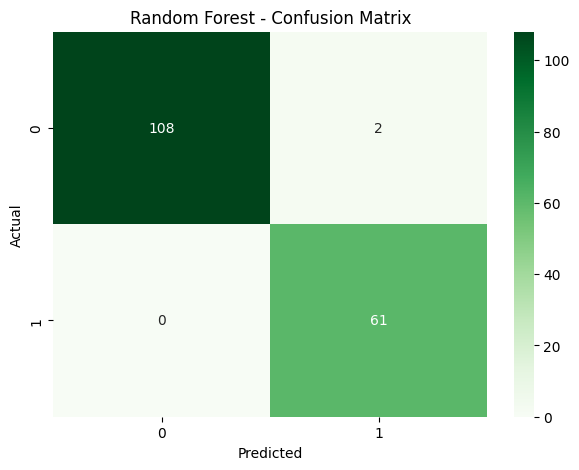

In [11]:
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Random Forest - Confusion Matrix')
plt.show()

In [12]:
# Visualise one tree from the forest

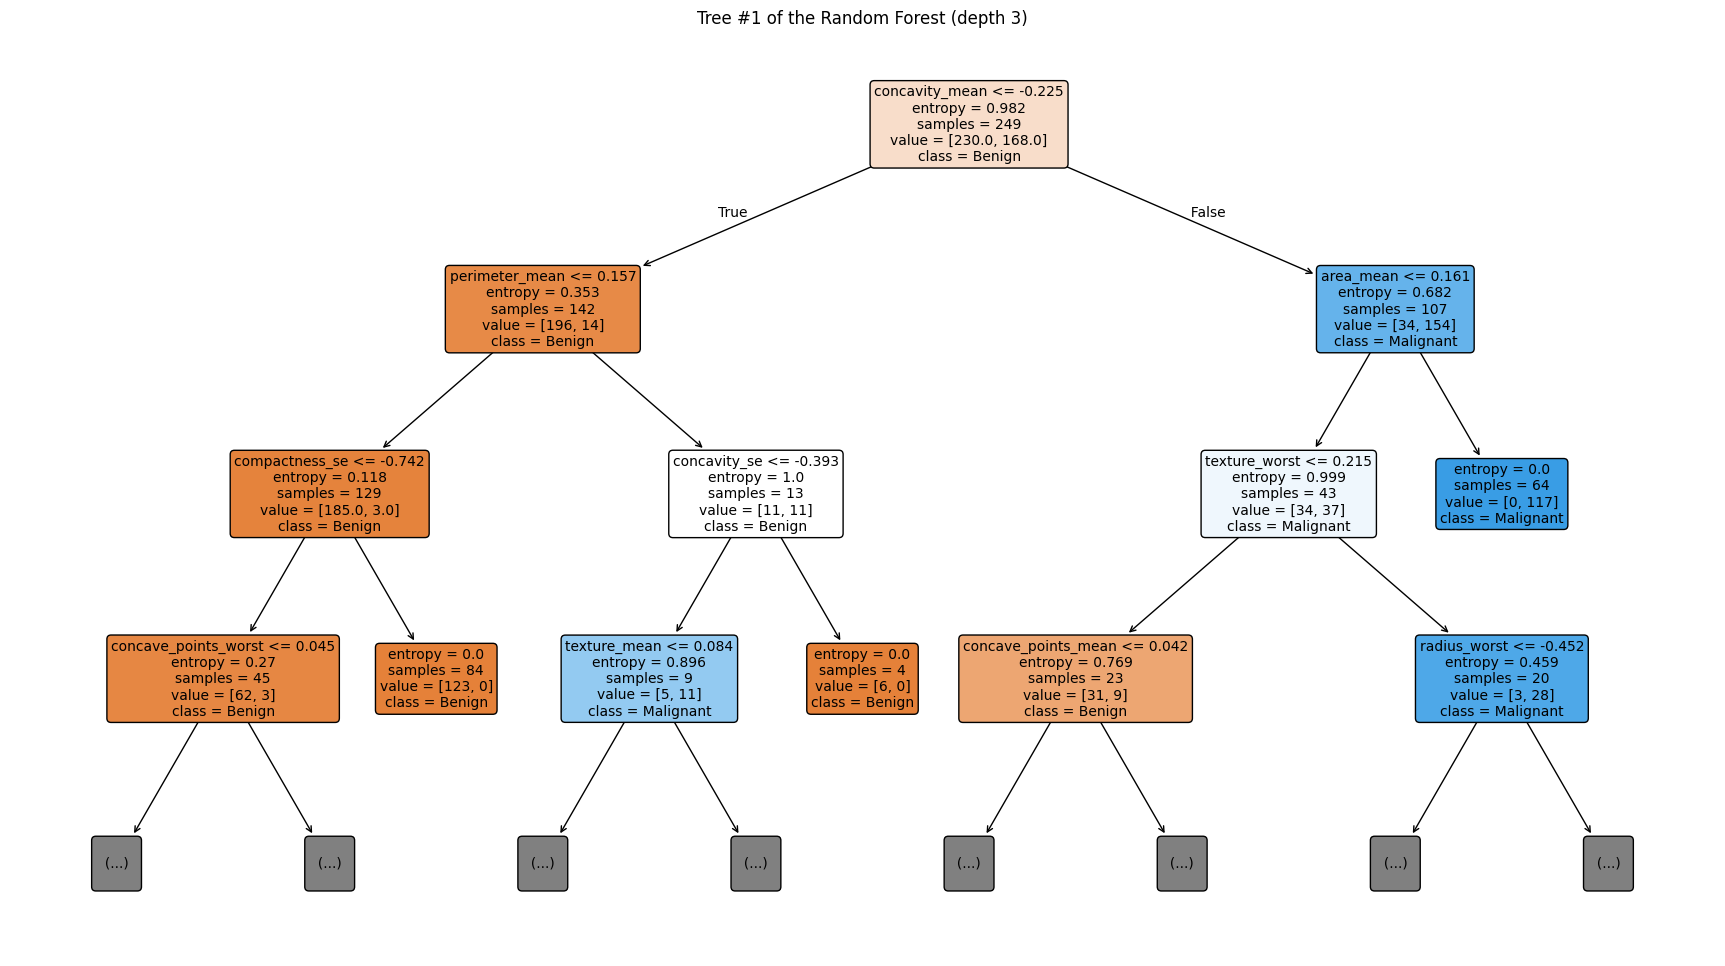

Tree depth: 7 leaves: 18


In [13]:
estimator = model.estimators_[0]

plt.figure(figsize=(22, 12))
plot_tree(estimator,
          feature_names=data.drop(columns=['id', 'diagnosis']).columns.tolist(),
          class_names=['Benign', 'Malignant'],
          filled=True, rounded=True, fontsize=10, max_depth=3)
plt.title('Tree #1 of the Random Forest (depth 3)')
plt.show()

print("Tree depth:", estimator.get_depth(), "leaves:", estimator.get_n_leaves())

In [14]:
# Feature Importance

                    Feature  Importance
27     concave_points_worst    0.152979
7       concave_points_mean    0.140411
23               area_worst    0.117675
13                  area_se    0.097530
6            concavity_mean    0.080392
3                 area_mean    0.072993
10                radius_se    0.036482
20             radius_worst    0.036331
0               radius_mean    0.035123
22          perimeter_worst    0.029060
12             perimeter_se    0.027482
21            texture_worst    0.023142
1              texture_mean    0.020068
29  fractal_dimension_worst    0.013296
2            perimeter_mean    0.013085


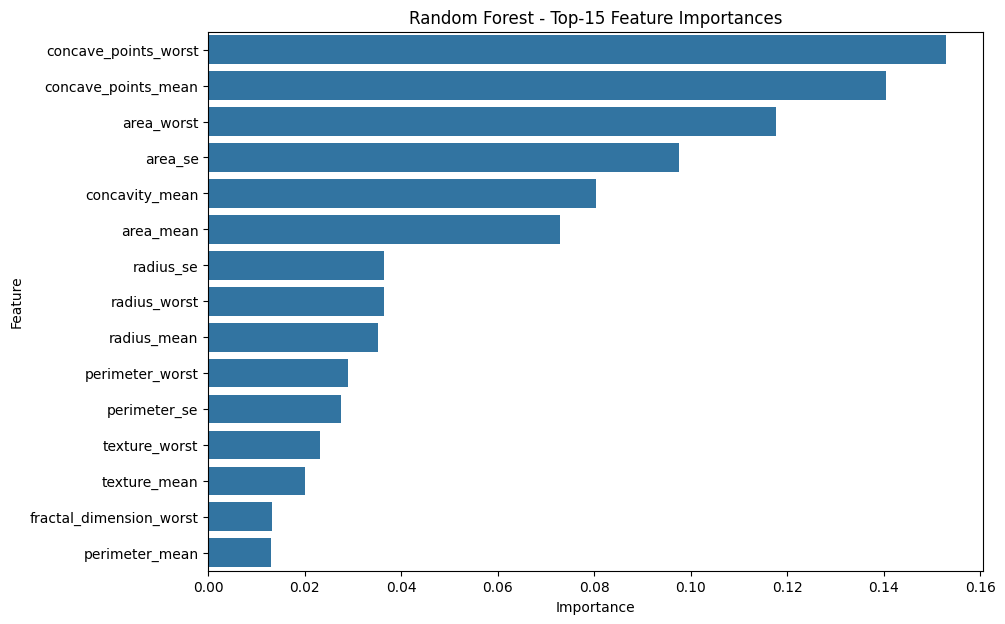

In [15]:
feat_names = data.drop(columns=['id', 'diagnosis']).columns.tolist()
importance = pd.DataFrame({
    'Feature'    : feat_names,
    'Importance' : model.feature_importances_,
}).sort_values('Importance', ascending=False)

print(importance.head(15))

plt.figure(figsize=(10, 7))
sns.barplot(x='Importance', y='Feature', data=importance.head(15))
plt.title('Random Forest - Top-15 Feature Importances')
plt.show()

In [16]:
# Accuracy vs number of trees

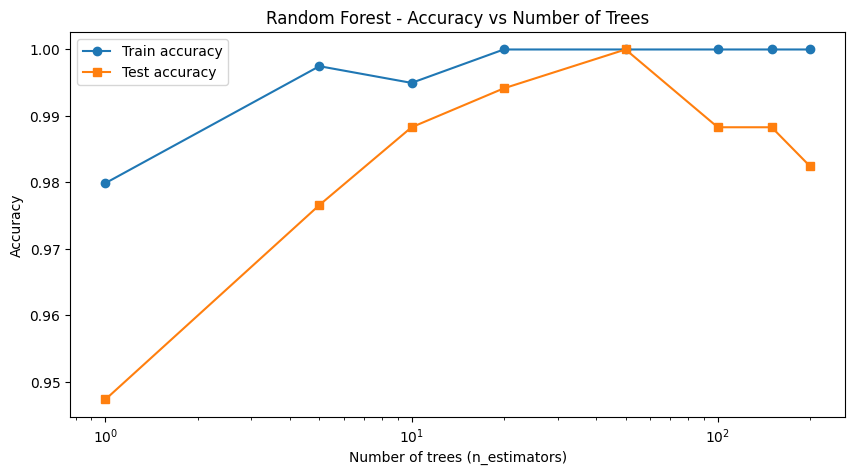

In [17]:
n_trees = [1, 5, 10, 20, 50, 100, 150, 200]
trains, tests = [], []
for n in n_trees:
    m = RandomForestClassifier(n_estimators=n, criterion='entropy',
                              random_state=0)
    m.fit(X_train_scaled, y_train)
    trains.append(m.score(X_train_scaled, y_train))
    tests.append(m.score(X_test_scaled, y_test))

plt.figure(figsize=(10, 5))
plt.plot(n_trees, trains, 'o-', label='Train accuracy')
plt.plot(n_trees, tests,  's-', label='Test accuracy')
plt.xscale('log')
plt.xlabel('Number of trees (n_estimators)')
plt.ylabel('Accuracy')
plt.title('Random Forest - Accuracy vs Number of Trees')
plt.legend()
plt.show()

In [18]:
# Out-of-Bag Score

In [19]:
model_oob = RandomForestClassifier(n_estimators=100, criterion='entropy',
                                  random_state=0, oob_score=True)
model_oob.fit(X_train_scaled, y_train)
print("OOB score (n_estimators=100):", round(model_oob.oob_score_, 4))
print("Test accuracy               :", round(model_oob.score(X_test_scaled, y_test), 4))

OOB score (n_estimators=100): 0.9523
Test accuracy               : 0.9883
